# Goal
I'm going to walk through how to create a basic machine learning (ML) model. It goes over some of the fundamentals of the optimizer behind the model. In later blog posts, I'll layer on additional complexity. Also, throughout this blog post, I'll scatter terminology in and try my best to define as I go.

### The model

The first model that we'll estimate parameters for with a ML model is below: 
$$
\begin{aligned}
y &\sim N(\mu, \sigma) \\
\mu &= ax^2 + bx + c
\end{aligned}
$$

This quadratic function can be estimated very simply with a linear regression, but starting out simple is good. Let's simulate some data from our generative model and plot it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import fastai.basics as fb

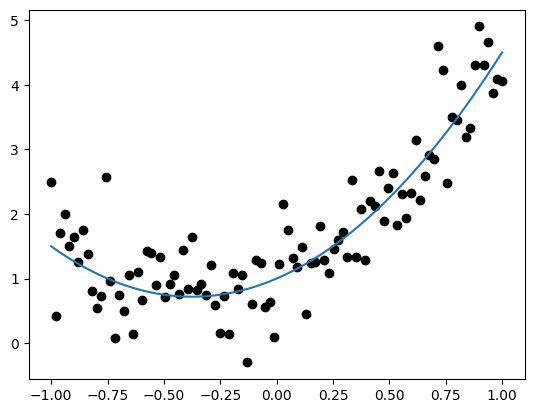

In [3]:
# generate data
def mod(x, a, b, c):
    return a*x**2 + b*x + c
    
def pred_mod(x, a, b, c, sigma):
    mu = mod(x, a, b, c)
    y = np.random.normal(mu, sigma, 1)[0]
    return y, mu

# get x values
n = 50
x = np.linspace(-1, 1, 100)

# define parameters
a, b, c, sigma = (2, 1.5, 1, .5)

# generate predictions
res = [pred_mod(x_i, a, b, c, sigma) for x_i in x]
y, mu = zip(*res)
df = pd.DataFrame({'x': x, 'y':y, 'mu': mu})

# visualize
plt.scatter(df['x'], df['y'], color = 'black')
plt.plot(df['x'], df['mu'])
plt.show()

### Gradient Descent
To estimate the best-fitting parameters in a machine learning model, we use "gradient descent" — an optimization algorithm that iteratively updates the model’s parameters to minimize a loss function.

Much like in frequentist statistics where we might minimize a negative log-likelihood, machine learning models also define a loss function that measures how well the model's predictions match the observed data. The optimizer computes the "gradients" — the partial derivatives of the loss with respect to each parameter — and uses them to adjust the parameters in the direction that reduces the loss. The adjustments are small, defined by the "learning rate", which tunes how much the parameters should step in a given direction. This process continues until the loss converges or meets some stopping criterion.


The general steps in optimizing the parameters are the following:

1. Ensure that you're working with tensors
2. define loss function
3. calculate loss with parameters
4. Calculate gradients
5. Adjust parameters using the gradients and learning rate
6. Zero out the gradients before next iteration
7. Repeat steps 3-6 until loss plateaus

To do all of this, the data (x), parameters (a, b, c), and predictions (y) need to be **tensors**, which are like `numpy` arrays, except track the gradients. 


*1. Tensors*

"Tensors" can be scalars, vectors, matrices, and arrays, which are 0-, 1-, 2-, and 3-rank tensors. I want the parameters and data to be 1-rank tensors. Importantly, we need to be able to track the gradients of the parameter tensor. 

In [4]:
# choose parameter values randomly
pars = fb.torch.randn(3)

# track the gradients. since function ends in '_', it acts inplace
pars.requires_grad_()

tensor([-0.6362,  1.1019, -0.3455], requires_grad=True)

In [5]:
# convert data--independent and dependent vars--to tensors
x = fb.torch.tensor(x)
y = fb.torch.tensor(y)

*2. Loss function*

Let's choose root mean squared error. The function will compute on tensors. 


In [6]:
def rmse(obs: fb.tensor, pred: fb.tensor):
    sq_error = (obs - pred)**2
    return sq_error.mean().sqrt()

*3. Calculate loss*

We calculate the loss on the predictions against the observed data. Predictions use the randomly chosen parameters from step 1. 

In [7]:
loss = rmse(y, mod(x, *pars))
loss

tensor(2.5031, dtype=torch.float64, grad_fn=<SqrtBackward0>)

*4. Calculate gradients*

A one liner with `backward()` on the loss tensor. No need to create a new object. 

In [8]:
loss.backward()

The gradients are now stored in the parameter tensor. If the gradient is negative, the loss decreases as the parameter increases, which means we would increase the parameter when we update it. Values closer to zero typically mean that we're converging towards a minimum of the loss function.  

In [9]:
pars.grad

tensor([-0.4130, -0.0455, -0.9175])

*5. Adjust parameters*

We use the gradients and a learning rate to adjust the parameters in the right direction. We want the steps to be small--too big might overshoot. Let's arbitrarily choose a learning rate of .01. When we do this, it's important to not track the gradients during the update process, which we can do by explicitly reassigning to the `data` attribute of the parameters tensor. 

In [10]:
lr = .01
pars.data -= pars.grad * lr

As you can see, our loss has decreased slightly in one iterative step. 

In [11]:
new_loss = rmse(y, mod(x, *pars))
print(f"Old loss: {loss}")
print(f"New loss: {new_loss}")

Old loss: 2.503129982359
New loss: 2.4929874340216456


*6. Zero out the gradients*

If you don't zero out the gradients, they start to add to one another. You want to calculate new gradients each step.

In [12]:
pars.grad.zero_()
pars.grad

tensor([0., 0., 0.])

*7. Put it all together in a loop*

I'll write a class for organizational sake.

In [13]:
class Optimizer:
    def __init__(self, x, y, pars, lr, model_fn = mod, loss_fn = rmse):
        self.x = x
        self.y = y
        self.pars = pars
        self.lr = lr
        self.model_fn = model_fn
        self.loss_fn = loss_fn
        self.loss_values = []

        # make sure pars are tracking gradients
        if not self.pars.requires_grad:
            self.pars.requires_grad_()

    def init_pars(self, n):
        # optional--in case you want to reinitiate pars
        self.pars = fb.torch.randn(n)
        self.pars.requires_grad_()

    def _calc_loss(self):
        # step 3 + 4
        y_hat = self.model_fn(self.x, *self.pars)
        loss = self.loss_fn(self.y, y_hat)
        loss.backward()
        self.loss_values.append(loss.item())

    def _adjust(self):
        # step 5
        self.pars.data -= self.pars.grad * self.lr

    def _zero(self):
        # step 6
        self.pars.grad.zero_()
    
    def train(self):
        # step 7--all together
        self._calc_loss()
        self._adjust()
        self._zero()


In [14]:
opt = Optimizer(x, y, pars, lr)
opt.init_pars(3)

iterations = range(0, 1000)
for i in iterations:
    opt.train()


The more iterations, the lower the loss. Also, the loss function flattens at the end, meaning we probably did enough training. 

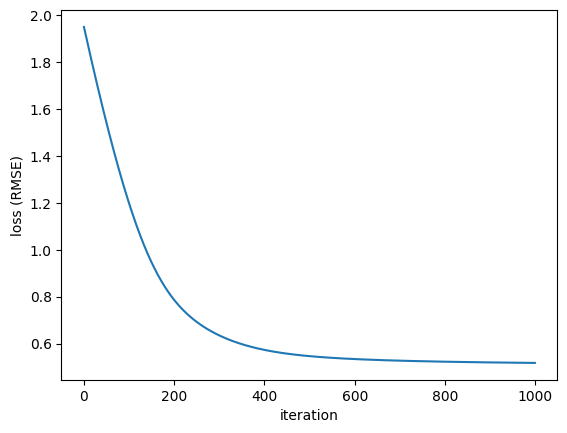

In [16]:

# check out change in loss
loss_df = pd.DataFrame({'i': iterations, 'loss': opt.loss_values})
plt.plot(loss_df['i'], loss_df['loss'])
plt.xlabel('iteration')
plt.ylabel('loss (RMSE)')
plt.show()

Now that's done, let's see how well our optimizer did to fit our model. IMO it did ok!

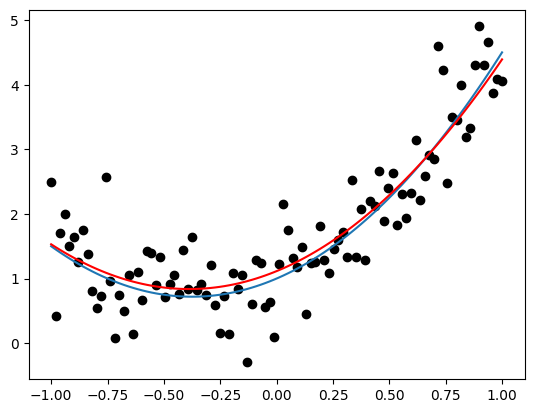

In [17]:
# Optimizer's predictions
y_hat = mod(x, *opt.pars)

# need to remove gradient tracker
df['pred'] = y_hat.detach() 

# plot 
plt.scatter(df['x'], df['y'], color = 'black')
plt.plot(df['x'], df['mu'])
plt.plot(df['x'], df['pred'], color = 'red')
plt.show()